import libreries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

In [2]:
import sys
print(sys.executable)

c:\Users\hp-pc\fraud-detection\.venv\Scripts\python.exe


load dataset

In [3]:
fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

ip = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

Section 3: Preview Dataset

In [4]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [5]:
ip.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


Section 4: Understand Dataset

In [6]:
fraud.shape

(151112, 11)

In [7]:
fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [8]:
fraud.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [9]:
fraud.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='object')

Section 5: Data Cleaning

In [10]:
fraud.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [11]:
fraud.duplicated().sum()

np.int64(0)

In [12]:
fraud.dtypes

user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object

Convert dates.

In [13]:
fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])

Section 6: Exploratory Data Analysis

array([[<Axes: title={'center': 'user_id'}>,
        <Axes: title={'center': 'signup_time'}>,
        <Axes: title={'center': 'purchase_time'}>],
       [<Axes: title={'center': 'purchase_value'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'ip_address'}>],
       [<Axes: title={'center': 'class'}>, <Axes: >, <Axes: >]],
      dtype=object)

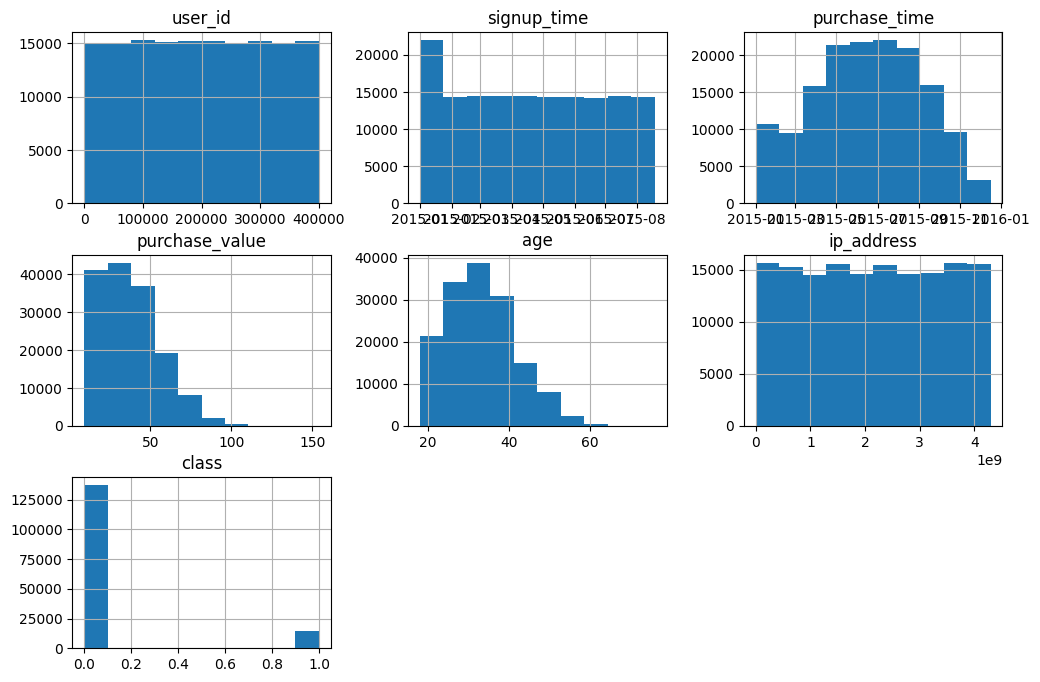

In [14]:
fraud.hist(figsize=(12,8))

<Axes: xlabel='purchase_value', ylabel='Count'>

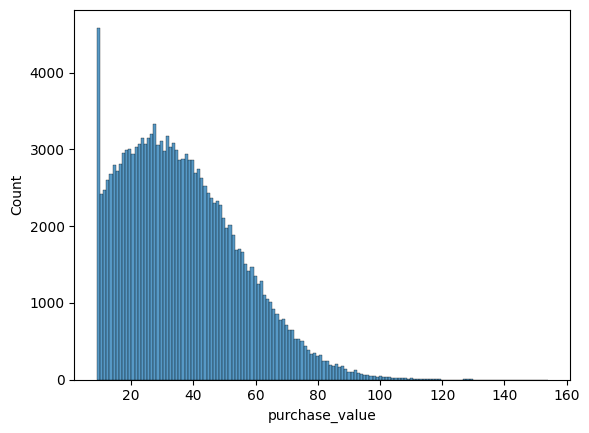

In [15]:
sns.histplot(fraud["purchase_value"])

<Axes: xlabel='browser', ylabel='count'>

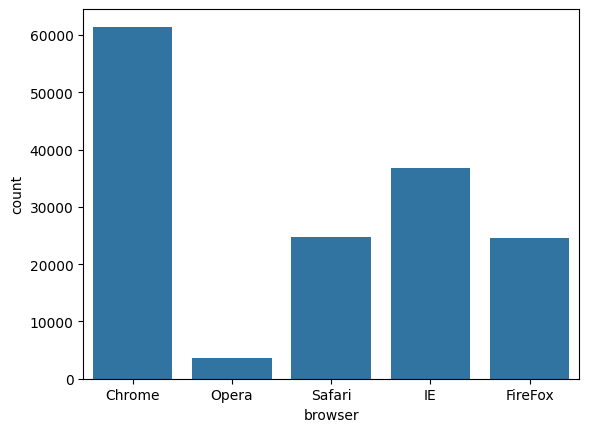

In [16]:
sns.countplot(x="browser", data=fraud)

<Axes: xlabel='source', ylabel='count'>

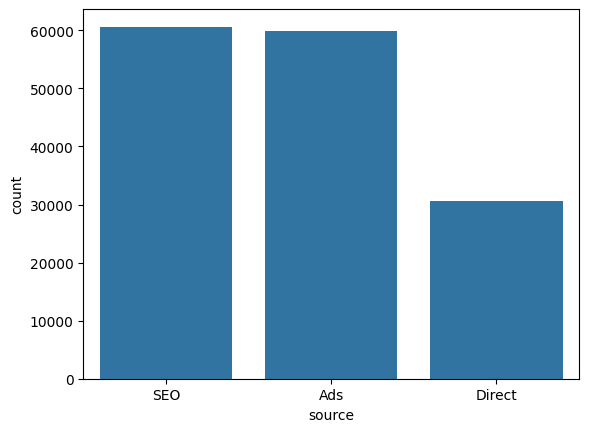

In [17]:
sns.countplot(x="source", data=fraud)

<Axes: xlabel='sex', ylabel='count'>

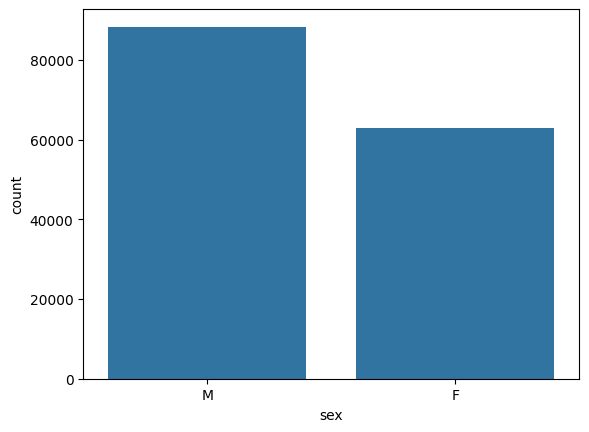

In [18]:
sns.countplot(x="sex", data=fraud)

<Axes: xlabel='purchase_value'>

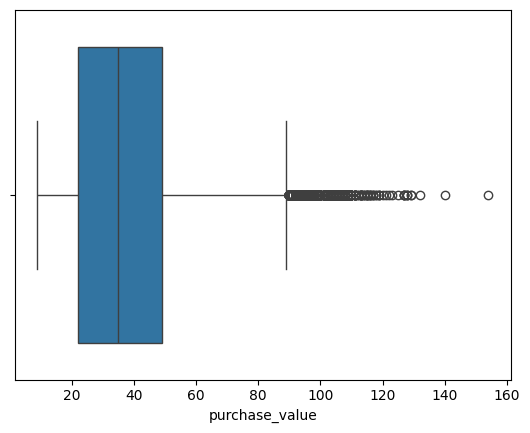

In [19]:
sns.boxplot(x=fraud["purchase_value"])

<Axes: xlabel='age'>

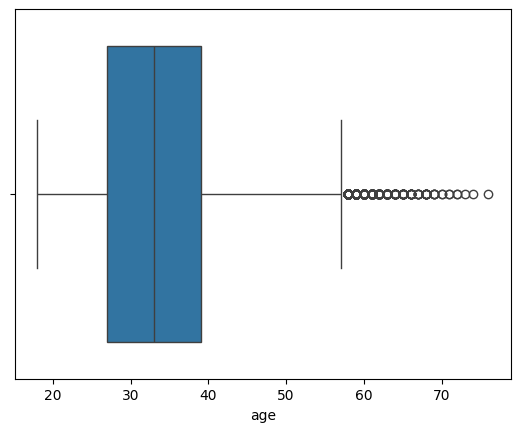

In [20]:
sns.boxplot(x=fraud["age"])

Section 8: Bivariate Analysis

<Axes: xlabel='class', ylabel='purchase_value'>

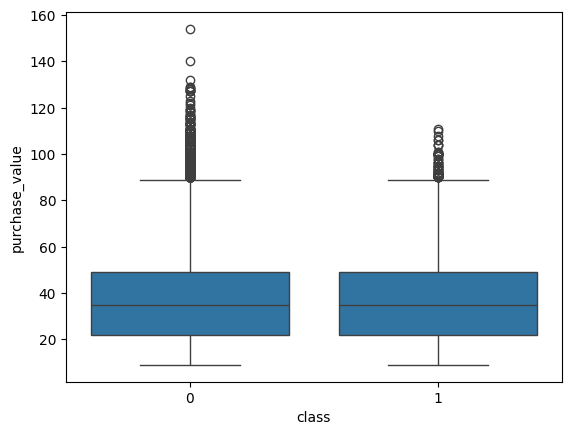

In [21]:
sns.boxplot(
    x="class",
    y="purchase_value",
    data=fraud
)

<Axes: xlabel='browser', ylabel='count'>

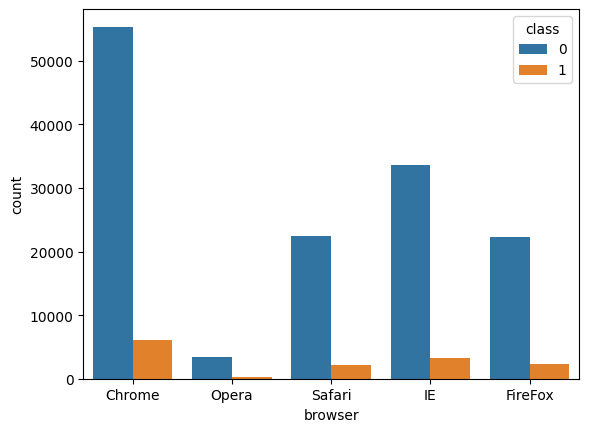

In [22]:
sns.countplot(
    x="browser",
    hue="class",
    data=fraud
)

<Axes: >

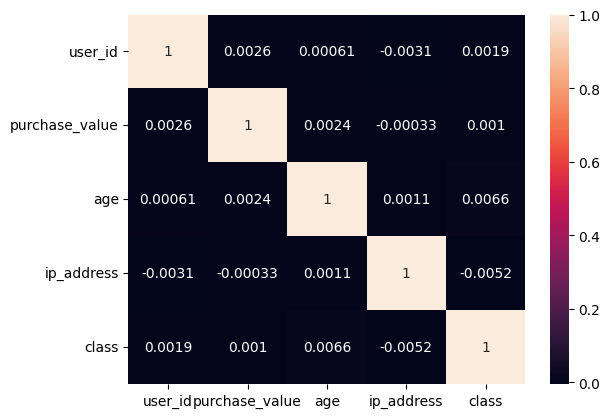

In [23]:
sns.heatmap(
    fraud.corr(numeric_only=True),
    annot=True
)

Section 9: Class Imbalance

In [24]:
fraud["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [25]:
fraud["class"].value_counts(normalize=True)

class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

<Axes: xlabel='class', ylabel='count'>

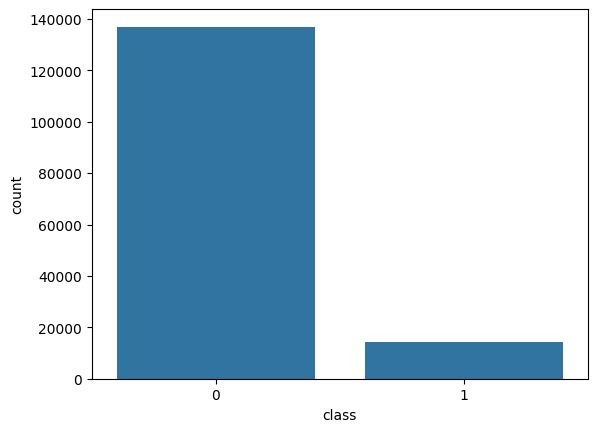

In [26]:
sns.countplot(x="class", data=fraud)

Section 10: Geolocation

In [27]:
fraud["ip_address"] = fraud["ip_address"].astype(int)

ip["lower_bound_ip_address"] = ip["lower_bound_ip_address"].astype(int)

ip["upper_bound_ip_address"] = ip["upper_bound_ip_address"].astype(int)

In [28]:
fraud = fraud.sort_values("ip_address")

ip = ip.sort_values("lower_bound_ip_address")

In [29]:
fraud = pd.merge_asof(
    fraud,
    ip,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [30]:
fraud = fraud[
    fraud["ip_address"] <= fraud["upper_bound_ip_address"]
]

In [31]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand


In [32]:
fraud[["ip_address", "country"]].head()

,ip_address,country
634,16778864,Australia
635,16842045,Thailand
636,16843656,China
637,16938732,China
638,16971984,Thailand


In [33]:
fraud.groupby("country")["class"].mean().sort_values(ascending=False)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
                           ...   
Uganda                   0.000000
Vanuatu                  0.000000
Yemen                    0.000000
Zambia                   0.000000
Zimbabwe                 0.000000
Name: class, Length: 181, dtype: float64

In [34]:
fraud["country"].value_counts()

country
United States                     58049
China                             12038
Japan                              7306
United Kingdom                     4490
Korea Republic of                  4162
                                  ...  
Dominica                              1
Gambia                                1
Vanuatu                               1
British Indian Ocean Territory        1
Nauru                                 1
Name: count, Length: 181, dtype: int64

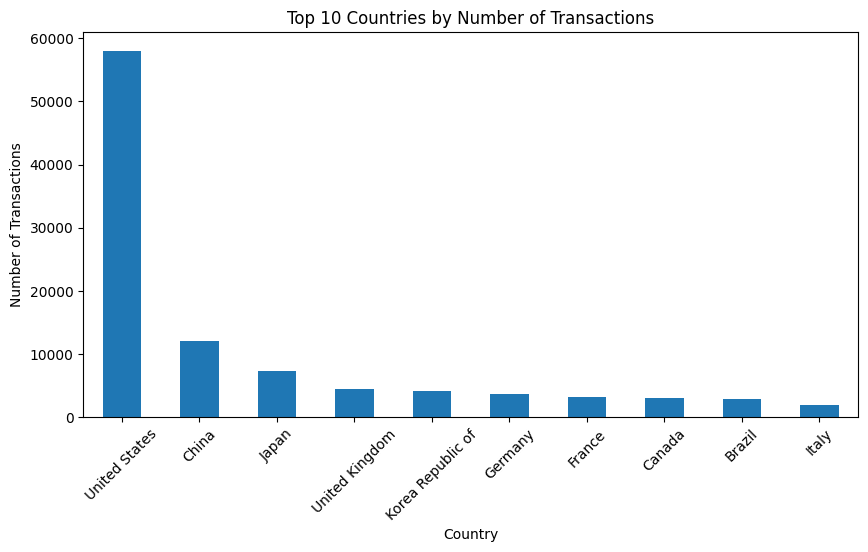

In [35]:
import matplotlib.pyplot as plt

top_countries = fraud["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

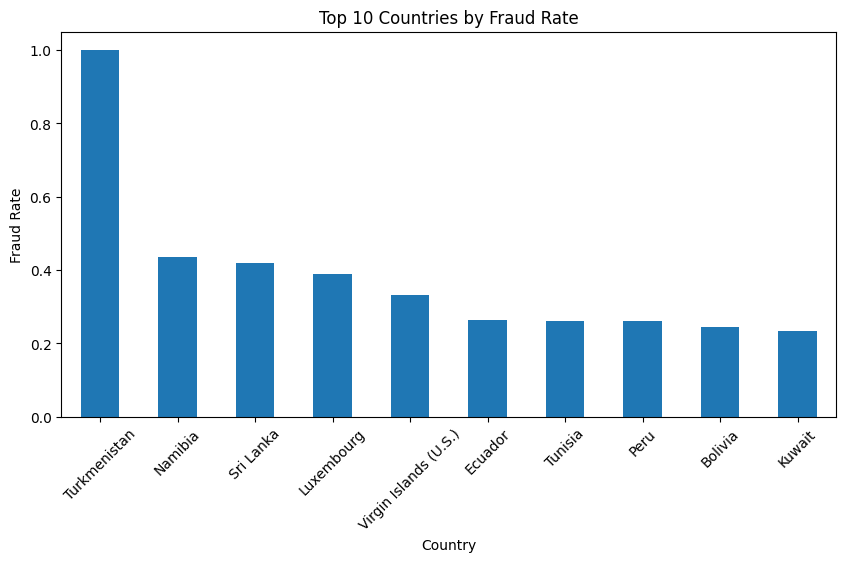

In [36]:
fraud_rate = fraud.groupby("country")["class"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
fraud_rate.plot(kind="bar")
plt.title("Top 10 Countries by Fraud Rate")
plt.xlabel("Country")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

In [37]:
fraud.to_csv("../data/processed/fraud_cleaned.csv", index=False)